## Sanjula Subhawickrama

# RAG Pipeline — Wikipedia Movie Plots → ChromaDB


## Requirements

In [1]:
# %pip install -q pandas chromadb sentence-transformers nltk tqdm matplotlib


In [2]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Blacksheep\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Blacksheep\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Blacksheep\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Load & Subset

In [3]:
import pandas as pd

DATA_PATH = "wiki_movie_plots_deduped.csv"

df_raw = pd.read_csv(DATA_PATH)
print(f"Raw rows: {len(df_raw)}")

# Keep only the columns we need
KEEP_COLS = ["Title", "Release Year", "Genre", "Director", "Cast", "Plot", "Origin/Ethnicity"]
df = df_raw[KEEP_COLS].copy()


Raw rows: 34886


In [4]:
# Drop rows with null/empty Plot or Title

df["Title"] = df["Title"].astype(str).str.strip()
df["Plot"] = df["Plot"].astype(str).str.strip()
df.loc[df["Title"].str.lower().isin(["nan", ""]), "Title"] = None
df.loc[df["Plot"].str.lower().isin(["nan", ""]), "Plot"] = None
df = df.dropna(subset=["Title", "Plot"])

print(f"Rows after dropping null/empty Title or Plot: {len(df)}")

Rows after dropping null/empty Title or Plot: 34886


In [5]:
# Sample 300 rows for a manageable subset

df_subset = df.sample(n=300, random_state=42).reset_index(drop=True)
print(f"Subset shape: {df_subset.shape}")

df_subset.head()

Subset shape: (300, 7)


,Title,Release Year,Genre,Director,Cast,Plot,Origin/Ethnicity
0,The Day the Earth Stood Still,1951,science fiction,Robert Wise,"Michael Rennie, Patricia Neal","When a flying saucer lands in Washington, D.C....",American
1,The Burning,1981,horror,Tony Maylam,"Brian Matthews, Holly Hunter, Jason Alexander","One night at Camp Blackfoot, several campers p...",American
2,Nobel Chor,2012,suspense / drama,Suman Ghosh,"Mithun Chakraborty, Saswata Chatterjee, Sudipt...","The first Asian Nobel Laureate, Rabindranath T...",Bengali
3,Trent's Last Case,1952,detective,Herbert Wilcox,"Michael Wilding, Margaret Lockwood, Orson Welles",A major international financier is found dead ...,British
4,Aafat,1977,unknown,Atma Ram,"Navin Nischol, Leena Chandavarkar, Amjad Khan,...",Inspector Amar and Inspector Chhaya are after ...,Bollywood


## Exploratory Data Analysis (EDA)

Before cleaning/normalizing further, get a feel for the text itself — this is what actually informs the chunking config (~300 words, ~50-word overlap) used later in Step 3. Runs against `df` (the full cleaned-of-nulls corpus, ~29k rows), not the 300-row `df_subset`, so the picture reflects the real dataset rather than one random sample. Heavier per-row NLP ops (sentence tokenizing, word tokenizing) are run on a capped random sample for speed.

### Overview: Shape, Missing Values, Duplicates

In [6]:
print(f"Dataset shape (after dropping null/empty Title or Plot): {df.shape}")

print("\nMissing values per column:")
print(df.isna().sum())

print(f"\nUnique Titles: {df['Title'].nunique():,} / {len(df):,} rows")
print(f"Exact duplicate Title strings: {df['Title'].duplicated().sum():,}")

df.head(3)

Dataset shape (after dropping null/empty Title or Plot): (34886, 7)

Missing values per column:
Title                  0
Release Year           0
Genre                  0
Director               0
Cast                1422
Plot                   0
Origin/Ethnicity       0
dtype: int64

Unique Titles: 32,361 / 34,886 rows
Exact duplicate Title strings: 2,525


,Title,Release Year,Genre,Director,Cast,Plot,Origin/Ethnicity
0,Kansas Saloon Smashers,1901,unknown,Unknown,NaN,"A bartender is working at a saloon, serving dr...",American
1,Love by the Light of the Moon,1901,unknown,Unknown,NaN,"The moon, painted with a smiling face hangs ov...",American
2,The Martyred Presidents,1901,unknown,Unknown,NaN,"The film, just over a minute long, is composed...",American


### Plot Length Distribution (Words & Characters)

Directly motivates the ~300-word chunk target: shows what fraction of plots need to be split into multiple chunks at all.

Word count stats:
count    34886.000000
mean       372.493206
std        315.753223
min          2.000000
25%        122.000000
50%        284.000000
75%        581.000000
max       6752.000000
Name: Plot, dtype: float64


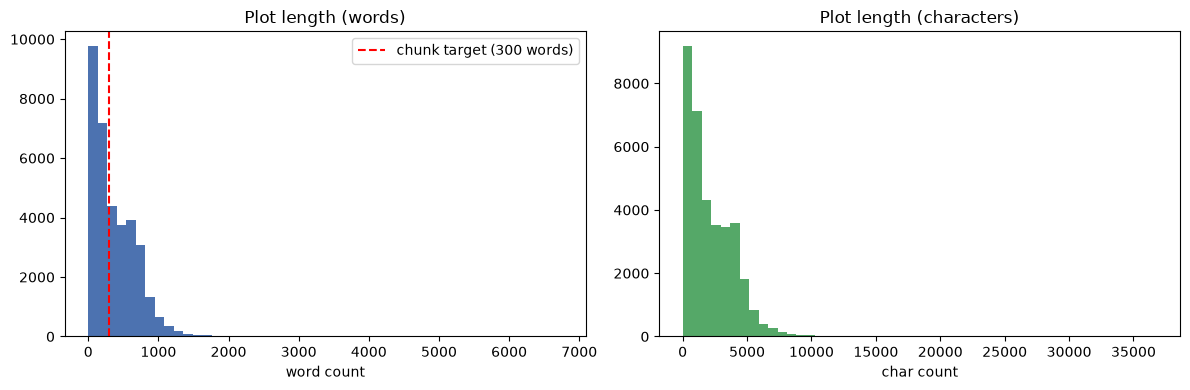


48.3% of plots exceed 300 words — these are the ones that get split into >1 chunk.


In [7]:
import matplotlib.pyplot as plt

plot_word_counts = df["Plot"].str.split().str.len()
plot_char_counts = df["Plot"].str.len()

print("Word count stats:")
print(plot_word_counts.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(plot_word_counts, bins=50, color="#4C72B0")
axes[0].axvline(300, color="red", linestyle="--", label="chunk target (300 words)")
axes[0].set_title("Plot length (words)")
axes[0].set_xlabel("word count")
axes[0].legend()

axes[1].hist(plot_char_counts, bins=50, color="#55A868")
axes[1].set_title("Plot length (characters)")
axes[1].set_xlabel("char count")

plt.tight_layout()
plt.show()

pct_over_300 = (plot_word_counts > 300).mean() * 100
print(f"\n{pct_over_300:.1f}% of plots exceed 300 words — these are the ones that get split into >1 chunk.")

### Token Count vs. BGE-small's 512-token Limit

Word counts above are a proxy — the embedding model actually truncates by **subword tokens**, not words, and silently drops anything past its limit. Load BGE-small's real tokenizer and measure: (a) how many full, unchunked plots would already exceed the limit, and (b) how many tokens a 300-word chunk slice actually costs — the number that really validates the Step 3 chunk-size choice.

e:\TypeB_Assignment\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (983 > 512). Running this sequence through the model will result in indexing errors


BGE-small max sequence length: 512 tokens

Full-plot token counts:
count    5000.000000
mean      476.951800
std       389.251545
min         5.000000
50%       373.000000
75%       737.000000
90%       995.000000
95%      1161.000000
max      6587.000000
Name: Plot, dtype: float64
% of full plots exceeding 512 tokens: 39.1%

Token counts for a 300-word chunk slice:
count    5000.000000
mean      284.131600
std       131.124462
min         5.000000
50%       357.000000
75%       390.000000
90%       413.000000
95%       429.000000
99%       461.000000
max       534.000000
Name: Plot, dtype: float64
Max tokens for a 300-word slice: 534
% of 300-word slices exceeding 512 tokens: 0.04%


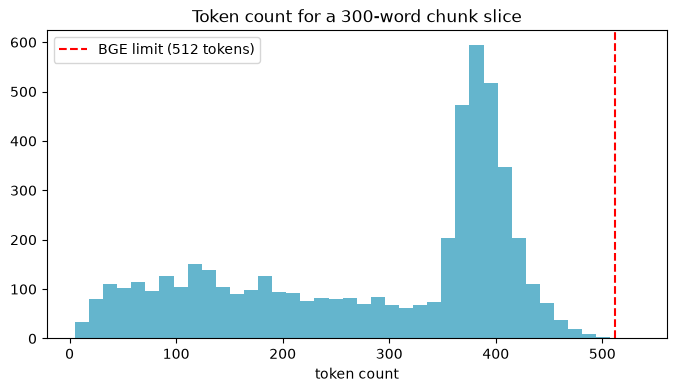

In [8]:
from transformers import AutoTokenizer

bge_tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-small-en-v1.5")
BGE_MAX_TOKENS = bge_tokenizer.model_max_length
EDA_SAMPLE_SIZE = 5000
print(f"BGE-small max sequence length: {BGE_MAX_TOKENS} tokens")

token_sample = df["Plot"].sample(min(EDA_SAMPLE_SIZE, len(df)), random_state=42)

# (a) full, untruncated plots -> shows why chunking is needed at all
full_token_counts = token_sample.apply(
    lambda t: len(bge_tokenizer.encode(str(t), add_special_tokens=True))
)
print("\nFull-plot token counts:")
print(full_token_counts.describe(percentiles=[.5, .75, .9, .95]))
print(f"% of full plots exceeding {BGE_MAX_TOKENS} tokens: {(full_token_counts > BGE_MAX_TOKENS).mean() * 100:.1f}%")

# (b) first ~300 words of each sampled plot -> empirical tokens-per-chunk at the chosen chunk size
chunk_slices = token_sample.apply(lambda t: " ".join(str(t).split()[:300]))
chunk_token_counts = chunk_slices.apply(
    lambda t: len(bge_tokenizer.encode(t, add_special_tokens=True))
)
print("\nToken counts for a 300-word chunk slice:")
print(chunk_token_counts.describe(percentiles=[.5, .75, .9, .95, .99]))
print(f"Max tokens for a 300-word slice: {chunk_token_counts.max()}")
print(f"% of 300-word slices exceeding {BGE_MAX_TOKENS} tokens: {(chunk_token_counts > BGE_MAX_TOKENS).mean() * 100:.2f}%")

plt.figure(figsize=(8, 4))
plt.hist(chunk_token_counts, bins=40, color="#64B5CD")
plt.axvline(BGE_MAX_TOKENS, color="red", linestyle="--", label=f"BGE limit ({BGE_MAX_TOKENS} tokens)")
plt.title("Token count for a 300-word chunk slice")
plt.xlabel("token count")
plt.legend()
plt.show()

### Sentences per Plot

Chunking is sentence-aware (`nltk.sent_tokenize`), so it's worth checking how many sentences a typical plot actually has — too few and overlap logic rarely kicks in, too many and a single plot could span many chunks.

Sentence count stats (n=2000 sampled plots):
count    2000.000000
mean       18.618500
std        16.373454
min         1.000000
25%         6.000000
50%        15.000000
75%        29.000000
max       326.000000
Name: Plot, dtype: float64


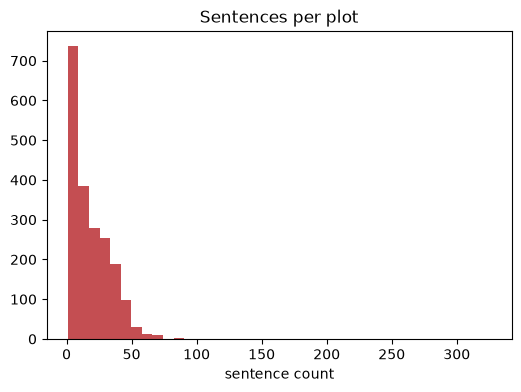

In [9]:
from nltk.tokenize import sent_tokenize

EDA_SAMPLE_SIZE = 2000  # cap for speed on the ~29k-row full corpus
sentence_sample = df["Plot"].sample(min(EDA_SAMPLE_SIZE, len(df)), random_state=42)
sentence_counts = sentence_sample.apply(lambda t: len(sent_tokenize(str(t))))

print(f"Sentence count stats (n={len(sentence_sample)} sampled plots):")
print(sentence_counts.describe())

plt.figure(figsize=(6, 4))
plt.hist(sentence_counts, bins=40, color="#C44E52")
plt.title("Sentences per plot")
plt.xlabel("sentence count")
plt.show()

### Vocabulary & Most Common Words

Rough diagnostic token frequency (lowercase, alphabetic tokens, English stopwords removed) — purely to sanity-check the corpus content before embedding. Not used anywhere downstream in the pipeline itself (recall from Steps 3-4: no stopword/punctuation removal happens there — the embedding model wants the full text).

Tokens scanned: 744,598 (from 2000 sampled plots)
Vocabulary size (unique tokens): 37,741
Vocabulary size excluding stopwords: 37,343


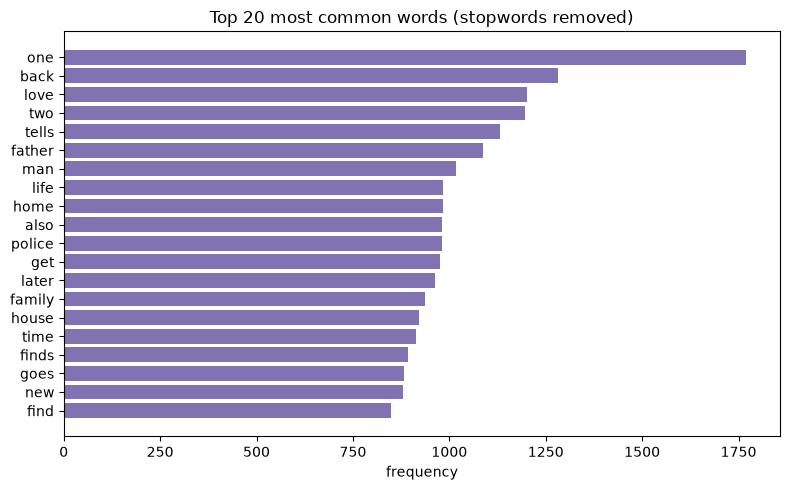

In [10]:
import re
from collections import Counter
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))


def tokenize_words(text):
    return re.findall(r"[a-z']+", str(text).lower())


vocab_sample = df["Plot"].sample(min(EDA_SAMPLE_SIZE, len(df)), random_state=42)
all_tokens = [tok for text in vocab_sample for tok in tokenize_words(text)]
content_tokens = [t for t in all_tokens if t not in stop_words and len(t) > 2]

print(f"Tokens scanned: {len(all_tokens):,} (from {len(vocab_sample)} sampled plots)")
print(f"Vocabulary size (unique tokens): {len(set(all_tokens)):,}")
print(f"Vocabulary size excluding stopwords: {len(set(content_tokens)):,}")

top_words = Counter(content_tokens).most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(8, 5))
plt.barh(words[::-1], counts[::-1], color="#8172B2")
plt.title("Top 20 most common words (stopwords removed)")
plt.xlabel("frequency")
plt.tight_layout()
plt.show()

### Genre & Release Year Spread

Raw values, before Step 2 normalizes `Genre` into a lowercased list — useful to see the messiness (multi-genre strings, inconsistent separators) that motivates that cleaning step.

Top 15 raw Genre values (uncleaned):
Genre
unknown            6083
drama              5964
comedy             4379
horror             1167
action             1098
thriller            966
romance             923
western             865
crime               568
adventure           526
musical             467
crime drama         464
romantic comedy     461
science fiction     418
film noir           345
Name: count, dtype: int64

Release Year range: 1901–2017
Rows with unparseable Release Year: 0 (dropped in Step 2)


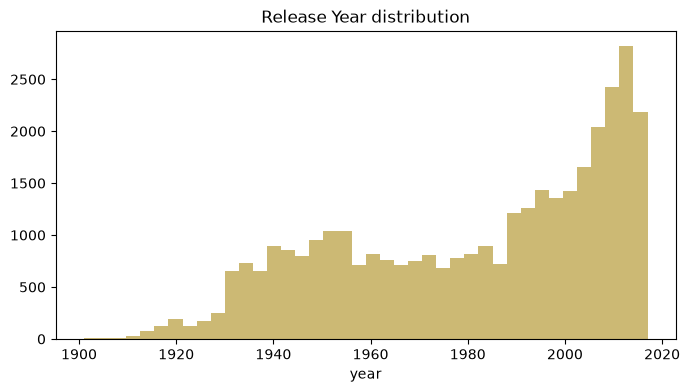

In [11]:
print("Top 15 raw Genre values (uncleaned):")
print(df["Genre"].value_counts().head(15))

years_numeric = pd.to_numeric(df["Release Year"], errors="coerce")
print(f"\nRelease Year range: {int(years_numeric.min())}–{int(years_numeric.max())}")
print(f"Rows with unparseable Release Year: {years_numeric.isna().sum()} (dropped in Step 2)")

plt.figure(figsize=(8, 4))
plt.hist(years_numeric.dropna(), bins=40, color="#CCB974")
plt.title("Release Year distribution")
plt.xlabel("year")
plt.show()

## Step 2: Clean & Normalize Metadata

- `Genre`: split on `/` and `,`, lowercase, strip, store as a list (max 3).
- `Cast`: split on `,`, keep the first 3 names as a list.
- `Director`: split on `,` (co-directors), strip, store as a list (max 3); `"Unknown"`/empty → `[]`.
- `Origin/Ethnicity`: split on `/` and `,`, lowercase, strip, store as a list (max 3); `"Unknown"`/empty → `[]`.
- `Release Year`: cast to int; drop rows where this fails.
- `Plot`: collapse whitespace/newlines and strip citation artifacts like `[1]`, `[edit]`.

> **Change note (list-valued metadata + `$contains`):** earlier, `Genre` got collapsed into one comma-joined *scalar* string per movie (`"drama, romance"`) because Chroma metadata was assumed to require scalar values — filtering then needed an exact match on the *entire* joined string, which was fragile. Testing directly against the installed chromadb (1.5.9) showed it actually **accepts list-valued metadata** and has a working `$contains` operator for membership filtering (`{"genre": {"$contains": "drama"}}` correctly matches a stored `["drama", "romance"]`, and doesn't false-positive on substrings of a scalar string). So `Genre`, `Director`, and `Origin/Ethnicity` are now all kept as lists all the way through to Chroma, and Step 3/6/`query_gemini.py` filter on them with `$contains` instead of `$eq`. One catch: Chroma rejects an *empty* list on upsert, so Step 3 omits the metadata key entirely for a chunk with no known genre/director/origin, rather than storing `[]`.

In [12]:
import re


def clean_genre(genre):
    """Split on '/' and ',', lowercase/strip, keep at most 3 genres."""
    if pd.isna(genre) or str(genre).strip() == "" or str(genre).strip().lower() == "unknown":
        return []
    parts = re.split(r"[/,]", str(genre))
    parts = [p.strip().lower() for p in parts if p.strip()]
    return parts[:3]


def clean_cast(cast):
    """Split on ',', keep the first 3 names."""
    if pd.isna(cast) or str(cast).strip() == "":
        return []
    parts = [p.strip() for p in str(cast).split(",") if p.strip()]
    return parts[:3]


def clean_director(director):
    """Split on ',' (co-directors), strip; keep at most 3 names as a list. 'Unknown'/empty -> []."""
    if pd.isna(director) or str(director).strip() == "" or str(director).strip().lower() == "unknown":
        return []
    parts = [p.strip() for p in str(director).split(",") if p.strip()]
    return parts[:3]


def clean_origin(origin):
    """Split on '/' and ',', lowercase/strip; keep at most 3 values as a list. 'Unknown'/empty -> []."""
    if pd.isna(origin) or str(origin).strip() == "" or str(origin).strip().lower() == "unknown":
        return []
    parts = re.split(r"[/,]", str(origin))
    parts = [p.strip().lower() for p in parts if p.strip()]
    return parts[:3]


def clean_plot(plot):
    """Collapse whitespace/newlines and strip citation artifacts like [1], [edit]."""
    text = str(plot)
    text = re.sub(r"\[[^\]]*\]", "", text)  # remove [1], [edit], [citation needed], ...
    text = re.sub(r"\s+", " ", text).strip()
    return text


df_subset["Genre"] = df_subset["Genre"].apply(clean_genre)
df_subset["Cast"] = df_subset["Cast"].apply(clean_cast)
df_subset["Director"] = df_subset["Director"].apply(clean_director)
df_subset["Origin/Ethnicity"] = df_subset["Origin/Ethnicity"].apply(clean_origin)
df_subset["Plot"] = df_subset["Plot"].apply(clean_plot)

# Release Year: cast to int; drop rows where this fails
df_subset["Release Year"] = pd.to_numeric(df_subset["Release Year"], errors="coerce")
before = len(df_subset)
df_subset = df_subset.dropna(subset=["Release Year"]).reset_index(drop=True)
df_subset["Release Year"] = df_subset["Release Year"].astype(int)
print(f"Dropped {before - len(df_subset)} rows with invalid Release Year")

print(f"Cleaned subset shape: {df_subset.shape}")
df_subset.head()

Dropped 0 rows with invalid Release Year
Cleaned subset shape: (300, 7)


,Title,Release Year,Genre,Director,Cast,Plot,Origin/Ethnicity
0,The Day the Earth Stood Still,1951,[science fiction],[Robert Wise],"[Michael Rennie, Patricia Neal]","When a flying saucer lands in Washington, D.C....",[american]
1,The Burning,1981,[horror],[Tony Maylam],"[Brian Matthews, Holly Hunter, Jason Alexander]","One night at Camp Blackfoot, several campers p...",[american]
2,Nobel Chor,2012,"[suspense, drama]",[Suman Ghosh],"[Mithun Chakraborty, Saswata Chatterjee, Sudip...","The first Asian Nobel Laureate, Rabindranath T...",[bengali]
3,Trent's Last Case,1952,[detective],[Herbert Wilcox],"[Michael Wilding, Margaret Lockwood, Orson Wel...",A major international financier is found dead ...,[british]
4,Aafat,1977,[],[Atma Ram],"[Navin Nischol, Leena Chandavarkar, Amjad Khan]",Inspector Amar and Inspector Chhaya are after ...,[bollywood]


## Step 2b: Resolve Duplicate (Title, Release Year) Rows

Two rows can share the exact same `Title` and `Release Year` for two different reasons, and they need different treatment:
- **Same movie, split/duplicated scrape** (director agrees, or is unknown on one/both sides) → merge the distinct plot text into a single row before chunking, so it isn't double-indexed as two separate movies.
- **Different movies that coincidentally share a title and year** (directors clearly disagree) → these are genuinely different films; merging their plots would corrupt both, so they're kept as separate rows instead. Step 3's id generation adds a `_dupN` suffix in this case so their chunk ids never collide in ChromaDB.

Merging is intentionally conservative — title+year alone can't safely prove two rows are the same film, so `Director` is used as the tiebreaker.

In [13]:
dup_mask = df_subset.duplicated(subset=["Title", "Release Year"], keep=False)
print(f"Rows sharing (Title, Release Year) with at least one other row: {dup_mask.sum()}")

if dup_mask.any():
    resolved_rows = []
    for (title, year), group in df_subset[dup_mask].groupby(["Title", "Release Year"], sort=False):
        # Director is now a list (co-directors) per row; compare via set overlap rather than
        # equality, so e.g. ["Ethan Coen", "Joel Coen"] still agrees with ["Ethan Coen"].
        director_sets = [set(d) for d in group["Director"] if d]  # non-empty lists only
        same_director = len(director_sets) <= 1 or len(set.intersection(*director_sets)) > 0

        if same_director:
            # Same movie (directors overlap, or unknown on one/both sides) -> merge distinct plots
            merged = group.iloc[0].copy()
            distinct_plots = list(dict.fromkeys(group["Plot"]))  # preserve order, drop exact dupes
            merged["Plot"] = " ".join(distinct_plots)
            resolved_rows.append(merged)
            print(f"  merged {len(group)} rows -> 1 for '{title}' ({year})")
        else:
            # Directors don't overlap at all -> different films sharing a title/year; keep both
            resolved_rows.extend(row for _, row in group.iterrows())
            all_directors = sorted(set.union(*director_sets))
            print(f"  kept {len(group)} rows separate for '{title}' ({year}) — directors differ: {all_directors}")

    df_subset = pd.concat(
        [df_subset[~dup_mask], pd.DataFrame(resolved_rows)],
        ignore_index=True,
    )

print(f"df_subset shape after duplicate resolution: {df_subset.shape}")

Rows sharing (Title, Release Year) with at least one other row: 0
df_subset shape after duplicate resolution: (300, 7)


## Step 2c: Metadata Category Reference (for the Gemini Query Planner)

`Genre` and `Origin/Ethnicity` are small, closed-ish vocabularies in this indexed subset — worth handing Gemini the *actual* list of values rather than making it guess spellings/casing (a guess that misses gets `$contains`-filtered to zero results). `Director` has far too many distinct, open-ended values to usefully enumerate, so it stays free-text.

This is computed straight from `df_subset` — the exact rows about to be chunked and indexed — and then written into `query_planner_prompt.md` between marker comments, so the prompt file used by `query_gemini.py` always reflects what's actually in the collection. Rerun this cell after resampling/reindexing to regenerate it.

In [14]:
from collections import Counter

genre_vocab = Counter(g for genres in df_subset["Genre"] for g in genres)
origin_vocab = Counter(o for origins in df_subset["Origin/Ethnicity"] for o in origins)
director_vocab = Counter(d for directors in df_subset["Director"] for d in directors)

print(f"Distinct genres ({len(genre_vocab)}):")
for g, c in genre_vocab.most_common():
    print(f"  {g!r}: {c}")

print(f"\nDistinct origins ({len(origin_vocab)}):")
for o, c in origin_vocab.most_common():
    print(f"  {o!r}: {c}")

print(f"\nDistinct directors: {len(director_vocab)} (too many/open-ended to enumerate in the prompt — left as free-text matching)")

Distinct genres (58):
  'drama': 75
  'comedy': 46
  'action': 18
  'thriller': 16
  'horror': 15
  'romance': 13
  'musical': 8
  'mystery': 7
  'crime': 6
  'family': 6
  'adventure': 5
  'crime drama': 4
  'animation': 4
  'romantic comedy': 4
  'fantasy': 4
  'war': 4
  'western': 4
  'science fiction': 3
  'sci-fi': 3
  'action thriller': 3
  'suspense': 2
  'animated': 2
  'family drama': 2
  'action drama': 2
  'comedy drama': 2
  'mockumentary': 2
  'comedy-drama': 2
  'musical comedy': 2
  'detective': 1
  'spy': 1
  'animated short': 1
  'martial arts': 1
  'melodrama': 1
  'coming of age': 1
  'sports': 1
  'biblical': 1
  'magical girl': 1
  'horror thriller': 1
  'bio-pic': 1
  'romantic action': 1
  'romantic drama': 1
  'social': 1
  'tokusatsu': 1
  'politics': 1
  'romance drama': 1
  "children's": 1
  'african drama': 1
  'psychological thriller': 1
  'biographical': 1
  'adaptation of a play by michel marc bouchard': 1
  'action comedy': 1
  'film noir': 1
  'family 

In [15]:
from pathlib import Path

PLANNER_PROMPT_PATH = Path("query_planner_prompt.md")
MARKER_START = "<!-- KNOWN_VALUES_START -->"
MARKER_END = "<!-- KNOWN_VALUES_END -->"

genre_list_md = ", ".join(f"`{g}`" for g in sorted(genre_vocab)) or "(none present)"
origin_list_md = ", ".join(f"`{o}`" for o in sorted(origin_vocab)) or "(none present)"

known_values_block = (
    f"{MARKER_START}\n"
    f"- **genre** values actually present in this collection: {genre_list_md}\n"
    f"- **origin** values actually present in this collection: {origin_list_md}\n"
    f"{MARKER_END}"
)

template = PLANNER_PROMPT_PATH.read_text(encoding="utf-8")
if MARKER_START not in template or MARKER_END not in template:
    raise ValueError(f"{PLANNER_PROMPT_PATH} is missing the {MARKER_START}/{MARKER_END} markers.")

pre, _, rest = template.partition(MARKER_START)
_, _, post = rest.partition(MARKER_END)
PLANNER_PROMPT_PATH.write_text(pre + known_values_block + post, encoding="utf-8")

print(f"Updated {PLANNER_PROMPT_PATH} with {len(genre_vocab)} genres and {len(origin_vocab)} origins.")

Updated query_planner_prompt.md with 58 genres and 17 origins.


## Step 3: Chunk Plot Text

Break each `Plot` into ~300-word, sentence-aware chunks with ~50-word overlap (never cutting mid-sentence) using `nltk.sent_tokenize`. Each chunk gets a metadata dict (`title`, `year`, `chunk_index`, plus `genre`/`director`/`origin` as **lists** whenever known — filterable in Chroma via `$contains`, and omitted entirely when empty since Chroma rejects empty-list metadata values) and a stable, slugified id `f"{title}_{year}_{chunk_index}"`.

In [16]:
from nltk.tokenize import sent_tokenize
from tqdm.auto import tqdm


def chunk_text(text, target_words=300, overlap_words=50):
    """Sentence-aware chunking: never split a sentence across chunks."""
    sentences = sent_tokenize(text)
    chunks = []
    current, current_wc = [], 0

    for sentence in sentences:
        sentence_wc = len(sentence.split())
        if current and current_wc + sentence_wc > target_words:
            chunks.append(" ".join(current))
            # carry the trailing ~overlap_words sentences into the next chunk
            overlap, overlap_wc = [], 0
            for s in reversed(current):
                s_wc = len(s.split())
                if overlap_wc + s_wc > overlap_words:
                    break
                overlap.insert(0, s)
                overlap_wc += s_wc
            current, current_wc = overlap, overlap_wc
        current.append(sentence)
        current_wc += sentence_wc

    if current:
        chunks.append(" ".join(current))
    return chunks


def slugify(text):
    """Lowercase, alnum-only, underscore-separated id fragment."""
    text = re.sub(r"[^a-z0-9]+", "_", str(text).lower())
    return text.strip("_")


records = []
seen_title_year = {}  # (slug_title, year) -> occurrences so far; guards against id collisions
                       # left over from Step 2b (distinct films that share a title + year)
for _, row in tqdm(df_subset.iterrows(), total=len(df_subset), desc="Chunking plots"):
    title, year = row["Title"], int(row["Release Year"])
    genre_list, director_list, origin_list = row["Genre"], row["Director"], row["Origin/Ethnicity"]
    slug_title = slugify(title)

    key = (slug_title, year)
    seen_title_year[key] = seen_title_year.get(key, 0) + 1
    dedup_suffix = f"_dup{seen_title_year[key]}" if seen_title_year[key] > 1 else ""

    for chunk_index, chunk in enumerate(chunk_text(row["Plot"])):
        metadata = {"title": title, "year": year, "chunk_index": chunk_index}
        # Chroma rejects an empty-list metadata value on upsert, so omit these keys
        # entirely for a chunk with no known genre/director/origin, rather than storing [].
        if genre_list:
            metadata["genre"] = genre_list
        if director_list:
            metadata["director"] = director_list
        if origin_list:
            metadata["origin"] = origin_list

        records.append({
            "id": f"{slug_title}_{year}{dedup_suffix}_{chunk_index}",
            "document": chunk,
            "metadata": metadata,
        })

print(f"Total chunks: {len(records)}")
records[0]

Chunking plots: 100%|██████████| 300/300 [00:00<00:00, 1457.47it/s]

Total chunks: 589


{'id': 'the_day_the_earth_stood_still_1951_0',
 'document': 'When a flying saucer lands in Washington, D.C., the Army quickly surrounds it. A humanoid (Michael Rennie) emerges, announcing that he has come in peace. When he unexpectedly opens a small device, he is shot by a nervous soldier. A tall robot emerges from the saucer and quickly disintegrates the soldiers\' weapons. The alien orders the robot, Gort, to stop. He explains that the now-broken device was a gift for the President which would have enabled him "to study life on the other planets". The alien, Klaatu, is taken to Walter Reed Hospital. After surgery, he uses a salve to quickly heal his wound. Meanwhile, the Army is unable to enter the saucer; Gort stands outside, silent and unmoving. Klaatu tells the President\'s secretary, Mr. Harley (Frank Conroy), that he has a message that must be delivered to all the world\'s leaders simultaneously. Harley tells him that such a meeting in the current political climate is impossible

## Step 4: Embed with BGE-small

Load `BAAI/bge-small-en-v1.5` and batch-encode the chunk documents (no query prefix needed here — bge's asymmetric instruction prefix only applies to queries at retrieval time). Embeddings are L2-normalized since bge is trained for cosine similarity.

In [17]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("BAAI/bge-small-en-v1.5")

documents = [r["document"] for r in records]
embeddings = embed_model.encode(
    documents,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,
)

print(f"Embeddings shape: {embeddings.shape}")

Batches: 100%|██████████| 19/19 [03:39<00:00, 11.53s/it]

Embeddings shape: (589, 384)


## Step 5: Store in ChromaDB

Create a persistent Chroma client, get/create the `movie_plots` collection (cosine space), and upsert ids/documents/embeddings/metadatas in batches.

In [18]:
import chromadb

chroma_client = chromadb.PersistentClient(path="./chroma_db")

collection = chroma_client.get_or_create_collection(
    name="movie_plots",
    metadata={"hnsw:space": "cosine"},
)

ids = [r["id"] for r in records]
metadatas = [r["metadata"] for r in records]

BATCH_SIZE = 32
for i in tqdm(range(0, len(records), BATCH_SIZE), desc="Upserting to Chroma"):
    batch = slice(i, i + BATCH_SIZE)
    collection.upsert(
        ids=ids[batch],
        documents=documents[batch],
        embeddings=embeddings[batch].tolist(),
        metadatas=metadatas[batch],
    )

print(f"Collection count: {collection.count()}")

Upserting to Chroma: 100%|██████████| 19/19 [00:05<00:00,  3.33it/s]

Collection count: 589


## Step 6: Sanity Check

Run one query that exercises both embedding search and metadata filtering (`where={"genre": {"$contains": ...}}`) end-to-end. `genre` is stored as a list per chunk, so `$contains` checks list membership (a movie tagged `["drama", "romance"]` matches a `"drama"` filter) rather than requiring an exact match on some joined string.

In [19]:
from collections import Counter

# genre is stored as a list per chunk now; flatten across all chunks to count individual values
genre_counts = Counter(g for m in metadatas for g in m.get("genre", []))
sample_genre = genre_counts.most_common(1)[0][0]
print(f"Filtering on genre containing {sample_genre!r}")

results = collection.query(
    query_texts=["a story about love and betrayal"],
    n_results=3,
    where={"genre": {"$contains": sample_genre}},
)

for i in range(len(results["ids"][0])):
    print(f"\nid: {results['ids'][0][i]}")
    print(f"metadata: {results['metadatas'][0][i]}")
    print(f"distance: {results['distances'][0][i]:.4f}")
    print(f"snippet: {results['documents'][0][i][:200]}...")

Filtering on genre containing 'drama'

id: the_idol_1966_0
metadata: {'genre': ['drama'], 'year': 1966, 'title': 'The Idol', 'origin': ['american'], 'chunk_index': 0, 'director': ['Daniel Petrie']}
distance: 0.7196
snippet: A rebellious student embarks on an affair with the mother of his best friend, leading to disastrous consequences....

id: speak_2004_1
metadata: {'director': ['Jessica Sharzer'], 'chunk_index': 1, 'year': 2004, 'title': 'Speak', 'genre': ['drama'], 'origin': ['american']}
distance: 0.7645
snippet: Melinda meets Rachel at the library and tells her the truth about what happened at the party by writing it on paper. Rachel first refuses to believe, thinking that Melinda is lying out of jealousy, an...

id: maa_1991_0
metadata: {'title': 'Maa', 'genre': ['drama'], 'chunk_index': 0, 'origin': ['bollywood'], 'director': ['Ajay Kashyap'], 'year': 1991}
distance: 0.7646
snippet: Ram Khanna is a wealthy industrialist with a trusting soul. Unknown to him, his elder brother Mur

## Step 7: Confirm the Vector DB is Persisted

`chromadb.PersistentClient` writes to `./chroma_db` on every `upsert` call — no separate save step is needed. To prove the data actually survived to disk (not just held in the live `collection` object from Step 5), open a **brand-new** client pointing at the same path and re-fetch the collection.

In [20]:
from pathlib import Path

verify_client = chromadb.PersistentClient(path="./chroma_db")
verify_collection = verify_client.get_collection("movie_plots")

print(f"Reopened '{verify_collection.name}' from disk — {verify_collection.count()} chunks stored.")
print(f"On-disk location: {Path('./chroma_db').resolve()}")

Reopened 'movie_plots' from disk — 589 chunks stored.
On-disk location: E:\TypeB_Assignment\chroma_db


## Step 8: Save ChromaDB → Handoff to `query_gemini.py`

Final save/handoff point. The collection is already durable on disk (Step 5's `upsert` + Step 7's reopen-and-verify), so this cell just pins down the exact on-disk location and collection name and confirms they match the defaults `query_gemini.py` loads (`CHROMA_PATH = "./chroma_db"`, `COLLECTION_NAME = "movie_plots"`) — run the CLI script from this same directory, or pass `--chroma-path` if you move it.

In [21]:
CHROMA_PATH = "./chroma_db"
COLLECTION_NAME = "movie_plots"

# Final explicit save point: PersistentClient flushes to disk on every write it has
# already seen (Step 5), so this just closes out the handle and re-confirms state.
save_client = chromadb.PersistentClient(path=CHROMA_PATH)
save_collection = save_client.get_collection(COLLECTION_NAME)

print("ChromaDB saved and ready for query_gemini.py")
print(f"  path:       {Path(CHROMA_PATH).resolve()}")
print(f"  collection: {save_collection.name!r}")
print(f"  chunks:     {save_collection.count()}")


ChromaDB saved and ready for query_gemini.py
  path:       E:\TypeB_Assignment\chroma_db
  collection: 'movie_plots'
  chunks:     589
